In [53]:
import pandas as pd


data = {
    'Name': ['Alice','Bob','Charile','David','Eve'],
    'Age': [25,30,35,40,28],
    'City':['New York','Los Angeles','Chicago','Houston','San Frecisco'],
    'Salary':[70000,80000,120000,90000,75000]
}
df = pd.DataFrame(data)
df

,Name,Age,City,Salary
0,Alice,25,New York,70000
1,Bob,30,Los Angeles,80000
2,Charile,35,Chicago,120000
3,David,40,Houston,90000
4,Eve,28,San Frecisco,75000


In [ ]:
# df['Country'] = ['USA', 'USA', 'USA', 'USA','USA']
# df['Country'] = ['USA']
df.loc[5] = ['Frank', 33, 'Seattle', 85000,'USA']
print(df)

      Name  Age          City  Salary Country
0    Alice   25      New York   70000     USA
1      Bob   30   Los Angeles   80000     USA
2  Charile   35       Chicago  120000     USA
3    David   40       Houston   90000     USA
4      Eve   28  San Frecisco   75000     USA
5    Frank   33       Seattle   85000     USA


In [ ]:
df = df.drop('Salary',axis = 1)
# df.drop('Salary',axis = 1,inplace = True) 동일 
df = df.drop(3)
df

,Name,Age,City,Country
0,Alice,25,New York,USA
1,Bob,30,Los Angeles,USA
2,Charile,35,Chicago,USA
4,Eve,28,San Frecisco,USA
5,Frank,33,Seattle,USA


In [ ]:

df.loc[df["Age"] >= 35, 'Salary'] = df['Salary'] * 1.05
df.loc[0, 'City'] = "Boston"
df




2    126000
3     94500
Name: Salary, dtype: int64


,Name,Age,City,Salary
0,Alice,25,Boston,70000
1,Bob,30,Los Angeles,80000
2,Charile,35,Chicago,132300
3,David,40,Houston,99225
4,Eve,28,San Frecisco,75000


In [22]:
df['Age'] = df['Age'].astype(float)
df['Salary'] = df['Salary'].astype(float)
print(df.dtypes)

Name       object
Age       float64
City       object
Salary    float64
dtype: object


### **[실습 1] 데이터 정리 및 전처리**

다음은 직장 내 직원 데이터입니다. 결측된 값들이 포함되어 있습니다. `Salary`와 `YearsAtCompany`의 결측값을 각 열의 평균값으로 채우세요.

In [6]:
import pandas as pd 
employee_data = {
    'EmployeeID': [101, 102, 103, 104, 105],
    'Name': ['John', 'Emily', 'Sara', 'Tom', 'Anna'],
    'Department': ['HR', 'IT', 'Marketing', None, 'HR'],
    'Salary': [50000, 70000, None, 45000, 52000],
    'YearsAtCompany': [5, None, 8, 3, 4]
}
pd = pd.DataFrame(employee_data)

pd['Salary'] = pd['Salary'].fillna(pd['Salary'].mean())
pd['YearsAtCompany'] = pd['YearsAtCompany'].fillna(pd['YearsAtCompany'].mean())
print(pd)

   EmployeeID   Name Department   Salary  YearsAtCompany
0         101   John         HR  50000.0             5.0
1         102  Emily         IT  70000.0             5.0
2         103   Sara  Marketing  54250.0             8.0
3         104    Tom       None  45000.0             3.0
4         105   Anna         HR  52000.0             4.0


### [실습 2] **중복값 제거**

다음은 한 판매점의 제품 판매 기록입니다. 동일한 제품이 중복으로 기록되어 있습니다. 중복된 `ProductID`를 가진 제품의 중복된 행을 제거한 후, 가장 저렴한 가격을 가진 데이터만 남기세요.

In [2]:
import pandas as pd 
product_data = {
    'ProductID': [1, 2, 3, 1, 4, 2],
    'ProductName': ['Laptop', 'Mouse', 'Monitor', 'Laptop', 'Keyboard', 'Mouse'],
    'Price': [1200, 25, 300, 1150, 45, 22],
    'QuantitySold': [10, 100, 50, 8, 70, 120]
}
df = pd.DataFrame(product_data)

# 중복값 제거
df = df.drop_duplicates(subset=["ProductID"])
df = df.drop_duplicates(subset=["Price"],keep ='first')
print(df)


   ProductID ProductName  Price  QuantitySold
0          1      Laptop   1200            10
1          2       Mouse     25           100
2          3     Monitor    300            50
4          4    Keyboard     45            70


### [실습 3] **데이터 정렬**

다음은 자동차 모델별 성능 데이터를 포함하고 있습니다. `마력(horsepower)`을 기준으로 오름차순으로 데이터를 정렬한 후, `연비(mpg)`가 높은 상위 3개 자동차만 출력하세요.

In [1]:
import pandas as pd
car_data = {
    'Model': ['Sedan', 'SUV', 'Truck', 'Coupe', 'Convertible'],
    'Horsepower': [180, 250, 200, 170, 150],
    'MPG': [30, 20, 15, 35, 28],
    'Price': [30000, 45000, 40000, 28000, 32000]
}
df = pd.DataFrame(car_data)

df_sorted = df.sort_values(by='Horsepower')
# 연비(mpg)`가 높은 상위 3개 자동차
df_filtered = df_sorted.nlargest(3,'MPG')
print(df_filtered)

         Model  Horsepower  MPG  Price
3        Coupe         170   35  28000
0        Sedan         180   30  30000
4  Convertible         150   28  32000


### [실습 4] **데이터 필터링**

다음은 축구 선수들의 데이터를 나타냅니다. 필터링을 통해 포지션이 "Forward"이고, 나이가 30 이하인 선수만 출력하세요.

In [4]:
football_data = {
    'PlayerID': [201, 202, 203, 204, 205],
    'Name': ['Ronaldo', 'Messi', 'Neymar', 'Mbappe', 'Kane'],
    'Position': ['Forward', 'Forward', 'Midfielder', 'Forward', 'Forward'],
    'GoalsScored': [600, 700, 400, 150, 200],
    'Age': [35, 33, 29, 22, 27]
}
df = pd.DataFrame(football_data)

df = df[(df['Position']=='Forward') & (df['Age'] >= 30 ) ]
df

,PlayerID,Name,Position,GoalsScored,Age
0,201,Ronaldo,Forward,600,35
1,202,Messi,Forward,700,33


## **[종합 실습 1] 상품 판매 데이터 분석**

다음은 한 전자상거래 사이트의 **상품 판매 데이터**입니다. 고객들이 특정 상품을 구매한 기록이 포함되어 있습니다. 데이터를 활용하여 아래의 문제를 해결하세요.

In [6]:
import pandas as pd

# 예시 상품 판매 데이터
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)

각 고객(CustomerID)별로 총 구매 금액을 계산하세요.

In [30]:
df_sales['Total'] = df_sales['Quantity'] * df_sales['Price']
grouped = df_sales.groupby('CustomerID')['Total'].sum()
print(grouped)

CustomerID
1001    3600
1002     250
1003     375
1004      50
1005     300
Name: Total, dtype: int64


Laptop을 구매한 고객들의 평균 구매 금액을 계산하세요.

In [41]:
#df_sales['Total'] = df_sales['Quantity'] * df_sales['Price']
#grouped = df_sales.groupby('Product')['Total'].mean()
#print(grouped["Laptop"])
laptop_sales = df_sales[df_sales['Product']== 'Laptop']
laptop_avg = laptop_sales['Total'].mean()
print(laptop_avg)




1200.0


가장 많이 판매된 상품(상품 이름과 판매된 총 수량)을 구하세요.

In [42]:
product_sales = df_sales.groupby('Product')['Quantity'].sum()
best_product = product_sales.idxmax()
best_product_qt = product_sales.max()

print(best_product,best_product_qt)

Mouse 7


OrderDate가 2024년 1월 10일 이후인 주문만 필터링하여 출력하세요.

In [ ]:
# to_datetime datetimed으로변환
filtered = df_sales[df_sales['OrderDate'] > '2024-01-10']
print(filtered)

   OrderID   Product  Quantity  Price  CustomerID   OrderDate  Total
4      105     Mouse         2     25        1004  2024-01-12     50
5      106  Keyboard         1    100        1002  2024-01-15    100
6      107    Laptop         1   1200        1001  2024-01-18   1200
7      108     Mouse         3     25        1003  2024-01-20     75
8      109   Monitor         1    300        1005  2024-01-22    300
9      110  Keyboard         1    100        1002  2024-01-25    100


Product별로 판매량과 총 판매 금액을 계산한 후, 이를 Price 기준으로 내림차순으로 정렬하여 출력하세요.

In [ ]:
#grouped_q = df_sales.groupby('Product')['Quantity'].sum()
#grouped_p= df_sales.groupby('Product')['Price'].sum()
result = df_sales.groupby('Product').agg(
    total_quantity=('Quantity', 'sum'),
    total_price=('Price', 'sum')
).sort_values('total_price',ascending=False)

print(result)


          total_quantity  total_price
Product                              
Laptop                 3         3600
Monitor                2          600
Keyboard               2          200
Mouse                  7           75


## [종합 실습 2] **컨텐츠 선호 데이터 분석**

다음은 사용자가 다양한 컨텐츠를 평가한 **컨텐츠 선호 데이터**입니다. 사용자가 영화, 음악, 책 등을 평가한 데이터를 바탕으로 분석을 수행하세요.

In [97]:
import pandas as pd

# 예시 컨텐츠 선호 데이터
preference_data = {
    'UserID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ContentID': [101, 102, 101, 103, 104, 105, 106, 101, 107, 102],
    'ContentType': ['Movie', 'Music', 'Movie', 'Book', 'Movie', 'Music', 'Book', 'Movie', 'Music', 'Book'],
    'Rating': [5, 3, 4, 2, 5, 4, 3, 4, 5, 2],
    'ReviewDate': ['2024-02-01', '2024-02-02', '2024-02-03', '2024-02-05', '2024-02-07', '2024-02-10', '2024-02-12', '2024-02-14', '2024-02-15', '2024-02-20']
}
df_preference = pd.DataFrame(preference_data)

각 컨텐츠 타입(ContentType)별로 평균 평점을 계산하세요.

In [ ]:
grouped = df_preference.groupby('ContentType')['Rating'].mean()
grouped

ContentType
Book     2.333333
Movie    4.500000
Music    4.000000
Name: Rating, dtype: float64

가장 높은 평점을 받은 ContentID와 해당 평점을 구하세요.

In [101]:
"""grouped = df_preference.groupby('ContentID',as_index=False)['Rating'].max()
max = df_preference.groupby('ContentID')['Rating'].max().max()
print(grouped)
print(max)
grouped = grouped[grouped['Rating']== max]
grouped"""
max = df_preference.loc[df_preference['Rating'].idxmax()]
print(max['ContentID'])
print(max['Rating'])


101
5


Movie 유형 컨텐츠에 대해 평점이 4 이상인 사용자들의 데이터를 필터링하세요.

In [ ]:
movie = df_preference[df_preference['ContentType'] == 'Movie']
filter =movie[movie['Rating'] >= 4]
print(filter)

   UserID  ContentID ContentType  Rating  ReviewDate
0       1        101       Movie       5  2024-02-01
2       3        101       Movie       4  2024-02-03
4       5        104       Movie       5  2024-02-07
7       8        101       Movie       4  2024-02-14


RviewDate`가 2024년 2월 10일 이후인 리뷰 중에서 `Rating`이 4 이상인 데이터를 필터링하여 출력하세요.

In [83]:
filtered = df_preference[df_preference['ReviewDate'] > '2024-02-10']
filter =filtered[filtered['Rating']>=4]
print(filter)

   UserID  ContentID ContentType  Rating  ReviewDate
7       8        101       Movie       4  2024-02-14
8       9        107       Music       5  2024-02-15


각 컨텐츠별(ContentID) 평가한  유저수를 계산하고, 이를 출력하세요.

In [106]:
count = df_preference.groupby('ContentID')['UserID'].count()
count 

ContentID
101    3
102    2
103    1
104    1
105    1
106    1
107    1
Name: UserID, dtype: int64

- **데이터 파일**: `ecommerce_sales_data.csv`
- **데이터 설명**:
    - **OrderID**: 주문 ID
    - **Product**: 주문한 상품 이름
    - **Category**: 상품의 카테고리 (예: Electronics, Clothing 등)
    - **Quantity**: 주문 수량
    - **Price**: 상품의 가격
    - **CustomerID**: 고객 ID
    - **BirthDate**: 고객 생일
    - **OrderDate**: 주문 날짜
    - **Country**: 주문한 고객의 국가

1. **데이터 탐색 및 전처리**
    1. 데이터셋을 로드하고 상위 5개의 데이터를 출력하세요.
    2. 결측값이 있는 열이 있는지 확인하고, 결측값이 있는 경우 적절한 방법으로 처리하세요.
    3. 각 열의 데이터 타입을 확인하고, **OrderDate** 열을 datetime 형식으로 변환하세요.

In [131]:
# 1-1번
import pandas as pd
df = pd.read_csv('ecommerce_sales_data.csv')
print(df.head())




   OrderID Product     Category  Quantity  Price  CustomerID   Birthdate  \
0        1     역사책        Books         5  37000        1071  1980-08-08   
1        2      셔츠     Clothing         5  20000        1526  1967-08-09   
2        3     노트북  Electronics         4   8000        1252  1973-04-07   
3        4     자전거       Sports         1   8000        1670  1970-04-08   
4        5     헤드폰  Electronics         3  26000        1838  1992-05-19   

          OrderDate Country  
0  2024-06-10 17:18      미국  
1  2023-11-18 18:45      독일  
2  2023-10-15 11:19      중국  
3   2024-07-19 2:19      일본  
4  2024-01-20 20:34    대한민국  


In [ ]:
# 1-2번
df = pd.read_csv('ecommerce_sales_data.csv')
df_cleaned = df.dropna()
print(df_cleaned)

     OrderID Product     Category  Quantity  Price  CustomerID   Birthdate  \
0          1     역사책        Books         5  37000        1071  1980-08-08   
1          2      셔츠     Clothing         5  20000        1526  1967-08-09   
2          3     노트북  Electronics         4   8000        1252  1973-04-07   
3          4     자전거       Sports         1   8000        1670  1970-04-08   
4          5     헤드폰  Electronics         3  26000        1838  1992-05-19   
..       ...     ...          ...       ...    ...         ...         ...   
115      116   스마트워치  Electronics         1  33000        1508  1971-01-02   
116      117   스마트워치  Electronics         4  41000        1645  1975-03-15   
117      118     태블릿  Electronics         1  33000        1433  1965-02-01   
118      119     청바지     Clothing         2  43000        1497  1980-04-02   
119      120      과자         Food         1  48000        1951  1989-11-28   

            OrderDate Country  
0    2024-06-10 17:18      미국  

In [ ]:
# 1-3번
import datetime 
print(df.dtypes)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
print(df.dtypes)

OrderID        int64
Product       object
Category      object
Quantity       int64
Price          int64
CustomerID     int64
Birthdate     object
OrderDate     object
Country       object
dtype: object
OrderID                int64
Product               object
Category              object
Quantity               int64
Price                  int64
CustomerID             int64
Birthdate             object
OrderDate     datetime64[ns]
Country               object
dtype: object


2. **매출 분석**
    1. **매출액**(총 판매 금액)을 계산하는 새로운 열 `TotalRevenue`를 생성하세요.
        - 매출액 = `Quantity` * `Price`
    2. 월별 총 매출액을 집계하여 시각화하세요.
        - 힌트: `resample()`을 사용하여 월별로 데이터를 집계하세요.
    3. 카테고리별로 매출액이 가장 높은 상위 3개의 카테고리를 구하세요.
    4. 국가별 총 매출액을 계산하고, 매출액이 가장 높은 5개 국가를 출력하세요.

In [ ]:
#2-1 
df["TotalRevenue"] = df["Quantity"] * df["Price"]
df

,OrderID,Product,Category,Quantity,Price,CustomerID,Birthdate,OrderDate,Country,TotalRevenue
0,1,역사책,Books,5,37000,1071,1980-08-08,2024-06-10 17:18:00,미국,185000
1,2,셔츠,Clothing,5,20000,1526,1967-08-09,2023-11-18 18:45:00,독일,100000
2,3,노트북,Electronics,4,8000,1252,1973-04-07,2023-10-15 11:19:00,중국,32000
3,4,자전거,Sports,1,8000,1670,1970-04-08,2024-07-19 02:19:00,일본,8000
4,5,헤드폰,Electronics,3,26000,1838,1992-05-19,2024-01-20 20:34:00,대한민국,78000
...,...,...,...,...,...,...,...,...,...,...
115,116,스마트워치,Electronics,1,33000,1508,1971-01-02,2024-03-01 16:57:00,독일,33000
116,117,스마트워치,Electronics,4,41000,1645,1975-03-15,2024-01-18 21:37:00,대한민국,164000
117,118,태블릿,Electronics,1,33000,1433,1965-02-01,2024-09-29 12:27:00,독일,33000
118,119,청바지,Clothing,2,43000,1497,1980-04-02,2024-06-10 09:01:00,독일,86000


/var/folders/g7/6_f4vlmd2tnf4ghbk1n9tv_40000gn/T/ipykernel_87159/85072745.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month = df.resample('M').sum()


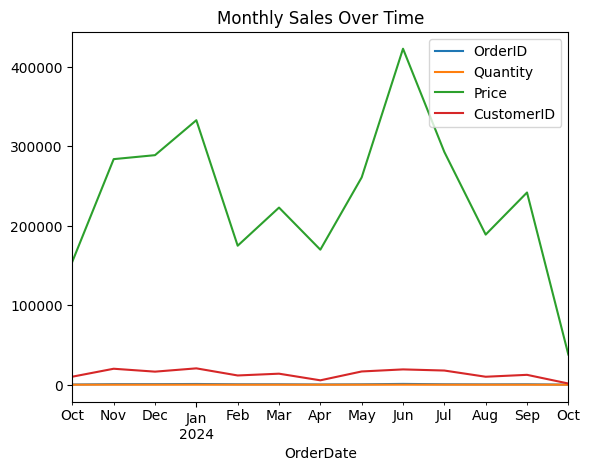

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('ecommerce_sales_data.csv')
print(df.head())

df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df.set_index('OrderDate',inplace=True)
month = df.resample('M').sum()

month.plot(title='Monthly Sales Over Time')
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('ecommerce_sales_data.csv')

df["TotalRevenue"] = df["Quantity"] * df["Price"]

# 2️⃣ 카테고리별 매출 합계
category = df.groupby("Category")["TotalRevenue"].sum()

top3_categories = category.sort_values(ascending=False).head(3)

print(top3_categories)

Category
Food           1966000
Electronics    1746000
Beauty         1493000
Name: TotalRevenue, dtype: int64


In [2]:
import pandas as pd

df = pd.read_csv('ecommerce_sales_data.csv')

df["TotalRevenue"] = df["Quantity"] * df["Price"]

Country = df.groupby("Country")["TotalRevenue"].sum()

top5_Country = Country.sort_values(ascending=False).head(5)

print(top5_Country)

Country
미국      2238000
독일      1973000
중국      1766000
일본      1523000
대한민국    1419000
Name: TotalRevenue, dtype: int64


3. **고객 분석**
    1. 고객별로 총 매출액을 계산한 후, 상위 5명의 고객을 출력하세요.
    2. 주문 횟수가 가장 많은 상위 5명의 고객을 출력하세요.
    3. **연령대**에 따라 고객을 분류하고, 각 연령대별로 가장 많이 구매한 상품의 카테고리를 구하세요.
        - 힌트: 고객의 연령대는 따로 제공되지 않으므로, 가정 데이터를 추가해 임의로 분류할 수 있습니다.

1. 고객별로 총 매출액을 계산한 후, 상위 5명의 고객을 출력하세요.

In [19]:
import pandas as pd
df = pd.read_csv('ecommerce_sales_data.csv')

df["TotalRevenue"] = df["Quantity"] * df["Price"]
top5_customers = (df.groupby("CustomerID",as_index = False)["TotalRevenue"]
    .sum()
    .sort_values("TotalRevenue",ascending=False)
    
)
print(top5_customers.head())


    CustomerID  TotalRevenue
0         1007        334000
33        1354        245000
16        1141        241000
69        1589        215000
74        1632        192000


2. 주문 횟수가 가장 많은 상위 5명의 고객을 출력하세요.

In [7]:
import pandas as pd
df = pd.read_csv('ecommerce_sales_data.csv')

top5_customers = df.groupby("CustomerID",as_index = False)["OrderID"].count().sort_values("OrderID",ascending=False).head()

top5_customers

,CustomerID,OrderID
0,1007,2
16,1141,2
82,1673,2
60,1508,2
43,1421,2


3. **연령대**에 따라 고객을 분류하고, 각 연령대별로 가장 많이 구매한 상품의 카테고리를 구하세요.
        - 힌트: 고객의 연령대는 따로 제공되지 않으므로, 가정 데이터를 추가해 임의로 분류할 수 있습니다.

4. **상품 분석**
    1. 가장 많이 판매된 상위 5개의 상품을 출력하세요.
    2. **카테고리별**로 가장 많이 판매된 상품을 찾아 출력하세요.
    3. **평균 구매 수량**이 가장 높은 상위 3개의 상품을 출력하세요.
5. **시간 분석**
    1. 주문 날짜별로 **주별** 매출액을 계산하고 시각화하세요.
    2. 특정 기간(예: 2024년 1월 ~ 2024년 6월) 동안의 매출 추이를 분석하고 시각화하세요.
    3. 특정 국가에서 가장 많이 주문한 시간대를 분석하고, 이를 시각화하여 인사이트를 도출하세요.

6. **추가 분석**
    1. 고객의 **재구매율**을 분석하세요.
        - 재구매율 = 한 고객이 여러 번 주문한 비율
    2. 상품 카테고리별 **할인**을 적용한 판매 데이터를 사용하여 할인율이 높은 카테고리의 매출액을 분석하세요.